# 🎯 Ejercicios Integradores

Cada ejercicio combina los dos módulos: primero detección clásica,
luego la transformación apropiada para mejorar el análisis.

| Ejercicio | Escenario | Detección | Transformación |
|---|---|---|---|
| **1** | Daños a terceros (severidad con ceros) | IQR + Z-Mod | `arcsinh`, `√x`, `log(x+1)` |
| **2** | Vida grupo por sucursal (frecuencia) | IQR por sucursal | `√x` + `arcsin(√p)` + IC 95% |
| **3** | Hogar: frecuencia + severidad | IQR en ambas dim. | `√x` (freq) + `arcsinh` (sev) |

## Ejercicio 1 — Severidad Daños a Terceros con Ceros

**Enunciado**

Una aseguradora tiene 180 siniestros de daños a terceros. Algunos fueron rechazados (monto = 0).

1. Detecta outliers con IQR y Z-Score Modificado en escala original
2. Aplica `√x`, `arcsinh(x/mediana)` y `log(x+1)` a los montos
3. Calcula asimetría (skewness) en cada escala y construye QQ-plots
4. Detecta outliers con IQR en cada escala transformada y compara
5. Calcula la prima pura con y sin outliers
6. ¿Cuál transformación es más apropiada para esta distribución?

**Pista**: Para arcsinh usa como referencia la mediana de los montos > 0.

In [17]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import poisson, lognorm, iqr
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Detección de outliers ──────────────────────────────────────


def detectar_outliers_zscore(serie, umbral=3):
    """Detección por Z-Score clásico."""
    return np.abs(stats.zscore(serie)) > umbral

def detectar_outliers_zscore_mod(serie, umbral=3.5):
    """Detección por Z-Score Modificado (robusto a outliers)."""
    mediana = serie.median()
    MAD = np.median(np.abs(serie - mediana))
    if MAD == 0:
        return pd.Series([False]*len(serie), index=serie.index)
    return 0.6745 * np.abs(serie - mediana) / MAD > umbral

def resumen_outliers(serie, nombre='Variable'):
    """Reporte comparativo de todos los métodos de detección."""
    _, out_iqr, li, ls = detectar_outliers_iqr(serie)
    out_z  = detectar_outliers_zscore(serie)
    out_zm = detectar_outliers_zscore_mod(serie)
    p99    = serie.quantile(0.99)
    print(f"\n{'='*55}")
    print(f"  📊 Resumen de Outliers: {nombre}")
    print(f"{'='*55}")
    print(f"  N total          : {len(serie):,}")
    print(f"  Media            : {serie.mean():,.2f}")
    print(f"  Mediana          : {serie.median():,.2f}")
    print(f"  Desv. Estándar   : {serie.std():,.2f}")
    print(f"  Mín / Máx        : {serie.min():,.2f} / {serie.max():,.2f}")
    print(f"  Percentil 99     : {p99:,.2f}")
    print(f"  Asimetría (skew) : {serie.skew():.3f}")
    print(f"  Curtosis         : {serie.kurtosis():.3f}")
    print(f"\n  --- Outliers detectados ---")
    print(f"  IQR (×1.5)       : {out_iqr.sum():,} ({out_iqr.mean()*100:.1f}%)  [>{ls:,.0f}]")
    print(f"  Z-Score (|z|>3)  : {out_z.sum():,} ({out_z.mean()*100:.1f}%)")
    print(f"  Z-Score Mod.     : {out_zm.sum():,} ({out_zm.mean()*100:.1f}%)")
    print(f"  Capping p99      : {(serie>p99).sum():,} ({(serie>p99).mean()*100:.1f}%)")
    print(f"{'='*55}")
    return {'iqr':out_iqr,'zscore':out_z,'zscore_mod':out_zm,
            'p99':serie>p99,'lim_sup_iqr':ls,'p99_val':p99}

def winsorizar(serie, p_inf=0.0, p_sup=0.99):
    """Winsorización entre percentiles."""
    return serie.clip(lower=serie.quantile(p_inf), upper=serie.quantile(p_sup))

# ── Transformaciones estabilizadoras ──────────────────────────

def t_sqrt(x):
    """Raíz cuadrada. x >= 0."""
    return np.sqrt(np.maximum(x, 0))

def t_arcsin_sqrt(p):
    """Arcoseno de raíz cuadrada. p en [0,1]."""
    return np.arcsin(np.sqrt(np.clip(p, 0, 1)))

def t_arcsinh(x, escala=1.0):
    """Arcoseno hiperbólico escalado. Funciona en x=0."""
    return np.arcsinh(x / escala)

def qqplot_ax(ax, data, titulo, color='#4C9BE8'):
    """QQ-plot Normal sobre un eje dado."""
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist='norm')
    ax.scatter(osm, osr, color=color, alpha=0.5, s=18, edgecolors='none')
    xl = np.array([min(osm), max(osm)])
    ax.plot(xl, slope*xl+intercept, 'r-', lw=2, label=f'R²={r**2:.3f}')
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('Cuantiles teóricos')
    ax.set_ylabel('Cuantiles observados')

print('✅ Setup completo — funciones de detección y transformación listas')

✅ Setup completo — funciones de detección y transformación listas


In [64]:
# ============================================================
# EJERCICIO 1 — Datos (no modificar)
# ============================================================
np.random.seed(99)
siniestros_base = np.random.lognormal(8.2, 0.7, 160)
siniestros_altos = np.array([95_000,120_000,85_000,140_000,200_000,
                               75_000,160_000,110_000,180_000,95_500])
ceros_ej1 = np.zeros(10)   # siniestros rechazados

siniestros_ej1 = pd.Series(
    np.concatenate([siniestros_base, siniestros_altos, ceros_ej1])
).round(2)

print(f'N total    : {len(siniestros_ej1)}')
print(f'Ceros      : {(siniestros_ej1==0).sum()}')
print(f'No-ceros   : {(siniestros_ej1>0).sum()}')
print(f'Skewness   : {siniestros_ej1.skew():.3f}')
print(f'Max        : ${siniestros_ej1.max():,.0f}')

N total    : 180
Ceros      : 10
No-ceros   : 170
Skewness   : 4.522
Max        : $200,000



  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 180
  Media            : 11,311.57
  Mediana          : 4,029.78
  Desv. Estándar   : 29,687.60
  Mín / Máx        : 0.00 / 200,000.00
  Percentil 99     : 164,200.00
  Asimetría (skew) : 4.522
  Curtosis         : 20.903

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.2%)  [>12,851]
  Z-Score (|z|>3)  : 6 (3.3%)
  Z-Score Mod.     : 13 (7.2%)
  Capping p99      : 2 (1.1%)


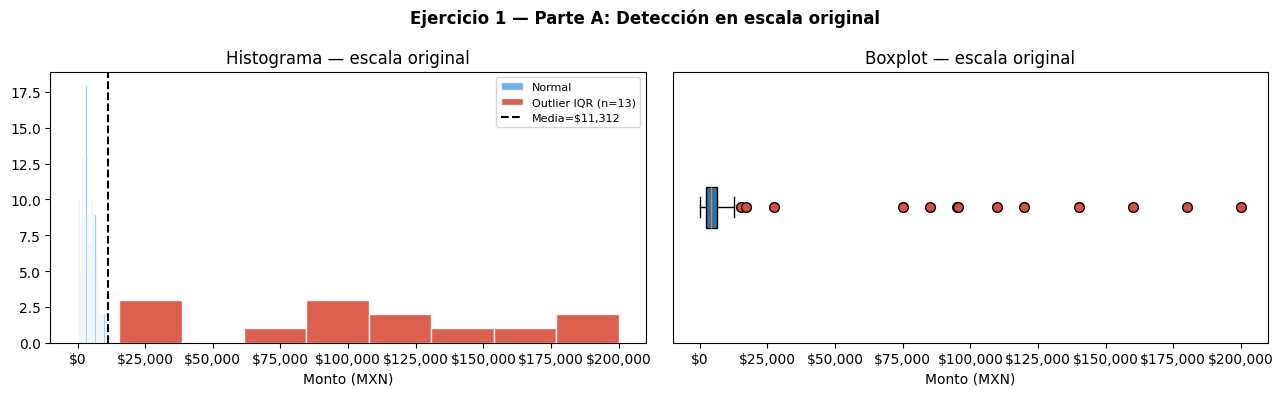


→ Continúa en la siguiente celda con las transformaciones (Parte B)


In [65]:
# ── PARTE A: Detección clásica en escala original ────────────
res_e1_orig = resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

# Visualización rápida
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
_, out_e1, _, ls_e1 = detectar_outliers_iqr(siniestros_ej1)
ax[0].hist(siniestros_ej1[~out_e1], bins=30, color='#4C9BE8', alpha=0.8,
           label='Normal', edgecolor='white')
ax[0].hist(siniestros_ej1[out_e1],  bins=8,  color='#D94F3D', alpha=0.9,
           label=f'Outlier IQR (n={out_e1.sum()})', edgecolor='white')
ax[0].axvline(siniestros_ej1.mean(), color='k', ls='--', lw=1.5,
              label=f'Media=${siniestros_ej1.mean():,.0f}')
ax[0].set_title('Histograma — escala original')
ax[0].set_xlabel('Monto (MXN)')
ax[0].legend(fontsize=8)
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))

ax[1].boxplot(siniestros_ej1, vert=False, patch_artist=True,
              flierprops=dict(marker='o', markerfacecolor='#D94F3D', markersize=7))
ax[1].set_title('Boxplot — escala original')
ax[1].set_xlabel('Monto (MXN)')
ax[1].set_yticks([])
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'${x:,.0f}'))
plt.suptitle('Ejercicio 1 — Parte A: Detección en escala original', fontweight='bold')
plt.tight_layout(); plt.show()

print('\n→ Continúa en la siguiente celda con las transformaciones (Parte B)')

In [66]:
#####  1. Detecta outliers con IQR y Z-Score Modificado en escala original    #####

siniestros_ej1 = siniestros_ej1[siniestros_ej1>0]
resumen_outliers(siniestros_ej1, 'Siniestros Daños a Terceros (MXN)')

## 1.1) Z-Score Modificado

from scipy.stats import median_abs_deviation
# Calcular mediana
mediana = np.median(siniestros_ej1)
# Calcular MAD
mad = median_abs_deviation(siniestros_ej1)
# Calcular M-scores modificados
m_scores = 0.6745 * np.abs(siniestros_ej1 - mediana) / mad
# Identificar outliers (M > 3.5)
outliers = np.where(m_scores > 3.5)[0]
print(f"Mediana: {mediana}")
print(f"MAD: {mad}")
print()
print(f"Outliers detectados: {len(siniestros_ej1[outliers])}")
print(f"Outliers:")
print(siniestros_ej1[outliers])



  📊 Resumen de Outliers: Siniestros Daños a Terceros (MXN)
  N total          : 170
  Media            : 11,976.96
  Mediana          : 4,380.98
  Desv. Estándar   : 30,421.84
  Mín / Máx        : 421.74 / 200,000.00
  Percentil 99     : 166,200.00
  Asimetría (skew) : 4.391
  Curtosis         : 19.603

  --- Outliers detectados ---
  IQR (×1.5)       : 13 (7.6%)  [>12,708]
  Z-Score (|z|>3)  : 6 (3.5%)
  Z-Score Mod.     : 13 (7.6%)
  Capping p99      : 2 (1.2%)
Mediana: 4380.985
MAD: 2027.41

Outliers detectados: 13
Outliers:
1       15368.19
32      17070.68
57      27248.46
160     95000.00
161    120000.00
162     85000.00
163    140000.00
164    200000.00
165     75000.00
166    160000.00
167    110000.00
168    180000.00
169     95500.00
dtype: float64


In [115]:
## 1.2) IQR
def detectar_outliers_iqr(datos, multiplicador=1.5):
    """
    Detecta outliers usando método IQR
    """
    Q1 = np.percentile(datos, 25)
    Q3 = np.percentile(datos, 75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - multiplicador * IQR
    limite_superior = Q3 + multiplicador * IQR
    outliers_mask = (datos < limite_inferior) | (datos > limite_superior)
    
    return {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'outliers': datos[outliers_mask],
        'indices': np.where(outliers_mask)[0]  }

# Usar función
resultado = detectar_outliers_iqr(siniestros_ej1)

print(f"Q1: {resultado['Q1']:.2f}")
print(f"Q3: {resultado['Q3']:.2f}")
print(f"IQR: {resultado['IQR']:.2f}")
print(f"Límite Superior: {resultado['limite_superior']:.2f}")
print(f"Outliers detectados: {len(resultado['outliers'])}")
print(f"Outliers:")
print(resultado['outliers'])

Q1: 2577.89
Q3: 6629.74
IQR: 4051.85
Límite Superior: 12707.51
Outliers detectados: 13
Outliers:
1       15368.19
32      17070.68
57      27248.46
160     95000.00
161    120000.00
162     85000.00
163    140000.00
164    200000.00
165     75000.00
166    160000.00
167    110000.00
168    180000.00
169     95500.00
dtype: float64


In [68]:
#####    2. Aplica √x, arcsinh(x/mediana) y log(x+1) a los montos    #####

print(f"Original:")
print(f"Monto mínimo: ${siniestros_ej1.min():.2f}")
print(f"Monto máximo: ${siniestros_ej1.max():.2f}")
print(f"Desviacion estandar: ${np.std(siniestros_ej1):.2f}")
print(siniestros_ej1[:2])


## 2.1) √x
siniestros_ej1_sqrt = np.sqrt(siniestros_ej1)
print()
print(f"Raiz cuadrada:")
print(f"Monto mínimo: ${siniestros_ej1_sqrt.min():.2f}")
print(f"Monto máximo: ${siniestros_ej1_sqrt.max():.2f}")
print(f"Desviacion estandar: ${np.std(siniestros_ej1_sqrt):.2f}")
print(siniestros_ej1_sqrt[:2])

## 2.2) arcsinh(x/mediana)
siniestros_ej1_arcsinh = np.arcsinh(siniestros_ej1/mediana)
print()
print(f"Arco seno hiperbolico:")
print(f"Monto mínimo: ${siniestros_ej1_arcsinh.min():.2f}")
print(f"Monto máximo: ${siniestros_ej1_arcsinh.max():.2f}")
print(f"Desviacion estandar: ${np.std(siniestros_ej1_arcsinh):.2f}")
print(siniestros_ej1_arcsinh[:2])

## 2.3) log(x+1)
siniestros_ej1_log = np.log(siniestros_ej1+1)
print()
print(f"Logaritmo+1 :")
print(f"Monto mínimo: ${siniestros_ej1_log.min():.2f}")
print(f"Monto máximo: ${siniestros_ej1_log.max():.2f}")
print(f"Desviacion estandar: ${np.std(siniestros_ej1_log):.2f}")
print(siniestros_ej1_log[:2])

Original:
Monto mínimo: $421.74
Monto máximo: $200000.00
Desviacion estandar: $30332.23
0     3295.62
1    15368.19
dtype: float64

Raiz cuadrada:
Monto mínimo: $20.54
Monto máximo: $447.21
Desviacion estandar: $71.73
0     57.407491
1    123.968504
dtype: float64

Arco seno hiperbolico:
Monto mínimo: $0.10
Monto máximo: $4.51
Desviacion estandar: $0.85
0    0.694951
1    1.967897
dtype: float64

Logaritmo+1 :
Monto mínimo: $6.05
Monto máximo: $12.21
Desviacion estandar: $1.06
0    8.100653
1    9.640120
dtype: float64


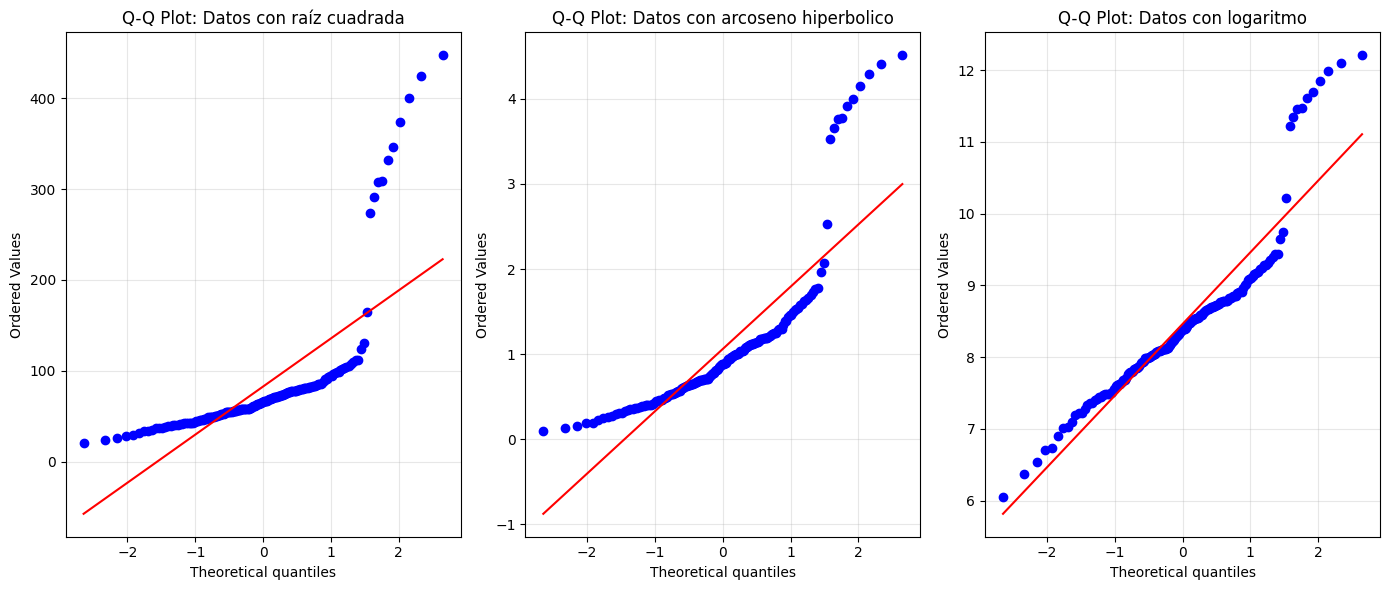

Datos con raíz cuadrada:
  Skewness: 3.423
  Kurtosis: 11.672

Datos con arcoseno hiperbolico:
  Skewness: 2.418
  Kurtosis: 6.165

Datos con logaritmo
  Skewness: 1.410
  Kurtosis: 3.212


In [69]:
#####   3. Calcula asimetría (skewness) en cada escala y construye QQ-plots   #####

# Crear figura con dos subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 6))

# QQ-plot para datos con raiz cuadrara
stats.probplot(siniestros_ej1_sqrt, dist="norm", plot=ax1)
ax1.set_title('Q-Q Plot: Datos con raíz cuadrada')
ax1.grid(True, alpha=0.3)

# QQ-plot para datos con arcoseno hiperbolico
stats.probplot(siniestros_ej1_arcsinh, dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot: Datos con arcoseno hiperbolico')
ax2.grid(True, alpha=0.3)

# QQ-plot para datos con logaritmo
stats.probplot(siniestros_ej1_log, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot: Datos con logaritmo')
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Interpretación
print("Datos con raíz cuadrada:")
print(f"  Skewness: {stats.skew(siniestros_ej1_sqrt):.3f}")
print(f"  Kurtosis: {stats.kurtosis(siniestros_ej1_sqrt):.3f}")

print("\nDatos con arcoseno hiperbolico:")
print(f"  Skewness: {stats.skew(siniestros_ej1_arcsinh):.3f}")
print(f"  Kurtosis: {stats.kurtosis(siniestros_ej1_arcsinh):.3f}")

print("\nDatos con logaritmo")
print(f"  Skewness: {stats.skew(siniestros_ej1_log):.3f}")
print(f"  Kurtosis: {stats.kurtosis(siniestros_ej1_log):.3f}")


In [ ]:
#####    4. Detecta outliers con IQR en cada escala transformada y compara    #####


# Usar función
resultado_sqr = detectar_outliers_iqr(siniestros_ej1_sqrt)
resultado_arcsinh = detectar_outliers_iqr(siniestros_ej1_arcsinh)
resultado_log = detectar_outliers_iqr(siniestros_ej1_log)

print('-'*80)
print(f"{'COMPARACIÓN: 3 Transformaciones':>60}")
print('-'*80)
print(f"{'Raíz cuadrada':>32} {'Arcoseno hip':>20} {'Logaritmo':>20}")
print(f"{'Q1:':<20} {resultado_sqr['Q1']:>10.2f} {resultado_arcsinh['Q1']:>20.2f} {resultado_log['Q1']:>20.2f}")
print(f"{'Q3:':<20} {resultado_sqr['Q3']:>10.2f} {resultado_arcsinh['Q3']:20.2f} {resultado_log['Q3']:>20.2f}")
print(f"{'IQR:':<20} {resultado_sqr['IQR']:>10.2f} {resultado_arcsinh['IQR']:>20.2f} {resultado_log['IQR']:>20.2f}")
print(f"{'Límite Superior:':<20}  {resultado_sqr['limite_superior']:>10.2f} {resultado_arcsinh['limite_superior']:>19.2f} {resultado_log['limite_superior']:>20.2f}")
print(f"{'Outliers detectados:':<20} {len(resultado_sqr['outliers']):>8} {len(resultado_arcsinh['outliers']):>22} {len(resultado_log['outliers']):>18}")    

# COMPARACION:
# La distirbucion con Arcoseno hip tiene un menor número de outliers
# La distribución con Logaritmo es la que presenta una mayor asimetria y kurtosis
# La distribución con Logaritmo es la que más se aproxima a una distribución normal

--------------------------------------------------------------------------------
                             COMPARACIÓN: 3 Transformaciones
--------------------------------------------------------------------------------
                   Raíz cuadrada         Arcoseno hip            Logaritmo
Q1:                       50.77                 0.56                 7.86
Q3:                       81.42                 1.20                 8.80
IQR:                      30.65                 0.64                 0.94
Límite Superior:          127.40                2.17                10.22
Outliers detectados:       12                     11                 12


In [ ]:
#####    5. Calcula la prima pura con y sin outliers    #####

siniestros_ej1_sinOut = siniestros_ej1[~siniestros_ej1.index.isin(resultado_log['outliers'].index)]

print(f"Prima pura con outliers:{round(sum(siniestros_ej1)/len(siniestros_ej1),2):>15}")
print(f"{'Outliers detectados:'} {len(resultado_log['outliers']):>15}")
print(f"Prima pura sin outliers:{round(sum(siniestros_ej1_sinOut)/len(siniestros_ej1_sinOut),2):>15}")

Prima pura con outliers:       11976.96
Outliers detectados:              12
Prima pura sin outliers:        4902.38


In [ ]:
#####    6. ¿Cuál transformación es más apropiada para esta distribución?    #####
# Logaritmo, ya que presenta una mayor asimetria y kurtosis, además, es la que más 
# se aproxima a una distribución normal


---
## Ejercicio 2 — Frecuencia de Incapacidad por Sucursal

**Enunciado**

Seguro de vida grupo, **120 empleados** en 5 sucursales. Variable: días de incapacidad/año.

1. Detecta sucursales con frecuencia atípica usando IQR global
2. Aplica `√x` a días individuales y re-detecta outliers
3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$
4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$
5. ¿Qué sucursales son estadísticamente atípicas? ¿El resultado cambia con la transformación?

In [93]:
# ============================================================
# EJERCICIO 2 — Datos provistos
# ============================================================

np.random.seed(77)

n_empleados = 120
sucursales = np.random.choice(['Norte', 'Sur', 'Este', 'Oeste', 'Centro'],
                               n_empleados)

# Siniestros de incapacidad (días ausentes en el año)
dias_base = {'Norte': 3, 'Sur': 4, 'Este': 5, 'Oeste': 3, 'Centro': 12}  # Centro es alta frecuencia
num_siniestros_ej2 = np.array([
    np.random.poisson(dias_base[s]) for s in sucursales
])

df_vida_grupo = pd.DataFrame({
    'Empleado_ID': range(1, n_empleados+1),
    'Sucursal': sucursales,
    'Dias_Incapacidad': num_siniestros_ej2
})

print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

Dataset: 120 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      19.0   2.95  1.65  0.0  2.00   3.0   4.0   6.0
Oeste      25.0   3.52  2.08  0.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0


In [133]:
df_vida_grupo = df_vida_grupo[df_vida_grupo.Dias_Incapacidad>0] 
print(f'Dataset: {len(df_vida_grupo)} empleados en {df_vida_grupo.Sucursal.nunique()} sucursales')
print('\nResumen por sucursal:')
print(df_vida_grupo.groupby('Sucursal')['Dias_Incapacidad'].describe().round(2))

Dataset: 117 empleados en 5 sucursales

Resumen por sucursal:
          count   mean   std  min   25%   50%   75%   max
Sucursal                                                 
Centro     32.0  12.41  3.56  7.0  9.75  13.0  14.0  19.0
Este       19.0   5.00  2.13  1.0  3.00   6.0   6.5   8.0
Norte      17.0   3.29  1.36  1.0  2.00   3.0   4.0   6.0
Oeste      24.0   3.67  1.99  1.0  2.00   4.0   5.0   8.0
Sur        25.0   4.40  2.36  1.0  3.00   4.0   5.0  10.0


In [134]:
#####    1. Detecta sucursales con frecuencia atípica usando IQR global    #####

freq_serie = df_vida_grupo['Dias_Incapacidad']
resultado = detectar_outliers_iqr(freq_serie)

print(f"Q1: {resultado['Q1']:.2f}")
print(f"Q3: {resultado['Q3']:.2f}")
print(f"IQR: {resultado['IQR']:.2f}")
print(f"Límite Superior: {resultado['limite_superior']:.2f}")
print(f"Outliers detectados: {len(resultado['outliers'])}")
print(f"Outliers:")
print(df_vida_grupo[df_vida_grupo.index.isin(resultado['outliers'].index)])

Q1: 3.00
Q3: 8.00
IQR: 5.00
Límite Superior: 15.50
Outliers detectados: 5
Outliers:
     Empleado_ID Sucursal  Dias_Incapacidad
21            22   Centro                18
78            79   Centro                17
97            98   Centro                18
101          102   Centro                19
109          110   Centro                19


In [ ]:
#####    2. Aplica `√x` a días individuales y re-detecta outliers    #####

freq_serie_sqrt = np.sqrt(df_vida_grupo['Dias_Incapacidad'])
resultado_sqrt = detectar_outliers_iqr(freq_serie_sqrt)

print(f"Q1: {resultado_sqrt['Q1']:.2f}")
print(f"Q3: {resultado_sqrt['Q3']:.2f}")
print(f"IQR: {resultado_sqrt['IQR']:.2f}")
print(f"Límite Superior: {resultado_sqrt['limite_superior']:.2f}")
print(f"Outliers detectados: {len(resultado_sqrt['outliers'])}")
print(f"Outliers:")
print(df_vida_grupo[df_vida_grupo.index.isin(resultado_sqrt['outliers'].index)])

Q1: 1.73
Q3: 2.83
IQR: 1.10
Límite Superior: 4.47
Outliers detectados: 0
Outliers:
Empty DataFrame
Columns: [Empleado_ID, Sucursal, Dias_Incapacidad]
Index: []


In [ ]:
#####    3. Calcula la tasa relativa por sucursal: $p_j = \bar{x}_j / \max(\bar{x})$    #####

# Tasa por sucursal
sucursal = df_vida_grupo.groupby('Sucursal').agg(
    Dias_Incapacidad  = ('Dias_Incapacidad',   'sum'),
    N= ('Sucursal', 'count'),
).round(2).reset_index()


sucursal['tasa'] = sucursal['Dias_Incapacidad'] / sucursal['N']         # continua, no normalizada
sucursal['tasa_norm'] = sucursal['tasa'] / sucursal['tasa'].max()               # normalizar a [0,1] para arcsin(√p)
sucursal


,Sucursal,Dias_Incapacidad,N,tasa,tasa_norm
0,Centro,397,32,12.406250,1.000000
1,Este,95,19,5.000000,0.403023
2,Norte,56,17,3.294118,0.265521
3,Oeste,88,24,3.666667,0.295550
4,Sur,110,25,4.400000,0.354660


In [145]:
#####    4. Aplica `arcsin(√p_j)` y construye IC al 95% con varianza estabilizada $\approx 1/(4n_j)$    #####

sucursal['arcsin_sqrt_p']  = t_arcsin_sqrt(sucursal['tasa_norm'])

# Varianza tras arcsin(√p) ≈ 1/(4n) — constante!
sucursal['var_arcsin'] = 1 / (4 * sucursal['N'])
sucursal

,Sucursal,Dias_Incapacidad,N,tasa,tasa_norm,arcsin_sqrt_p,var_arcsin
0,Centro,397,32,12.406250,1.000000,1.570796,0.007812
1,Este,95,19,5.000000,0.403023,0.687802,0.013158
2,Norte,56,17,3.294118,0.265521,0.541343,0.014706
3,Oeste,88,24,3.666667,0.295550,0.574774,0.010417
4,Sur,110,25,4.400000,0.354660,0.637929,0.010000


---
## Ejercicio 3 — Seguro de Hogar: Frecuencia + Severidad + Transformaciones

**Enunciado**

Portafolio de **130 pólizas** de hogar. Algunas pólizas no tuvieron siniestros (monto = 0).

1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original
2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)
3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad
4. Construye tabla comparativa de asimetría/curtosis antes y después
5. Detecta doble outlier en escala transformada: ¿coincide con el original?
6. Discute la **desigualdad de Jensen**: ¿puedes usar la media arcsinh para calcular la prima?

In [148]:
# ============================================================
# EJERCICIO 3 — Datos provistos
# ============================================================

np.random.seed(55)
n_polizas = 130

# Frecuencia: Poisson(1.5) con algunos outliers
freq_hogar = pd.Series(
    np.concatenate([
        np.random.poisson(1.5, 120),
        np.array([8, 10, 7, 9, 12, 6, 11, 8, 9, 7])
    ])
)

# Severidad promedio por póliza (MXN)
sev_hogar = pd.Series(
    np.concatenate([
        np.random.lognormal(9.0, 0.6, 120),
        np.array([450_000, 380_000, 520_000, 310_000, 600_000,
                  290_000, 475_000, 350_000, 410_000, 550_000])
    ])
).round(2)

df_hogar = pd.DataFrame({
    'Poliza_ID': range(1, n_polizas + 1),
    'Num_Siniestros': freq_hogar,
    'Monto_Promedio_MXN': sev_hogar
})
df_hogar['Costo_Total'] = df_hogar['Num_Siniestros'] * df_hogar['Monto_Promedio_MXN']

print(f'Dataset: {len(df_hogar)} pólizas de hogar')
print('\nEstadísticas:')
print(df_hogar[:3])
print()
print(df_hogar.describe().round(2))

Dataset: 130 pólizas de hogar

Estadísticas:
   Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
0          1               0            13080.87         0.00
1          2               2            12750.78     25501.56
2          3               1            10745.12     10745.12

       Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
count     130.00          130.00              130.00       130.00
mean       65.50            2.01            41788.53    306729.88
std        37.67            2.29           116951.19   1095056.71
min         1.00            0.00             2512.53         0.00
25%        33.25            1.00             5307.03      4217.53
50%        65.50            1.00             8424.76     10984.94
75%        97.75            2.00            11782.46     21785.43
max       130.00           12.00           600000.00   7200000.00


In [154]:
#####    1. Detecta outliers de frecuencia (IQR) y severidad (IQR) en escala original    #####

## 1.1) Outliers de frecuencia (IQR)
freq_serie = df_hogar[df_hogar.Num_Siniestros>0]['Num_Siniestros']
resultado_frec = detectar_outliers_iqr(freq_serie)

print(f"Q1: {resultado_frec['Q1']:.2f}")
print(f"Q3: {resultado_frec['Q3']:.2f}")
print(f"IQR: {resultado_frec['IQR']:.2f}")
print(f"Límite Superior: {resultado_frec['limite_superior']:.2f}")
print(f"Outliers detectados: {len(resultado_frec['outliers'])}")
print(f"Outliers:")
print(df_hogar[df_hogar.index.isin(resultado_frec['outliers'].index)])

Q1: 1.00
Q3: 3.00
IQR: 2.00
Límite Superior: 6.00
Outliers detectados: 9
Outliers:
     Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
120        121               8            450000.0    3600000.0
121        122              10            380000.0    3800000.0
122        123               7            520000.0    3640000.0
123        124               9            310000.0    2790000.0
124        125              12            600000.0    7200000.0
126        127              11            475000.0    5225000.0
127        128               8            350000.0    2800000.0
128        129               9            410000.0    3690000.0
129        130               7            550000.0    3850000.0


In [ ]:
## 1.2) Outliers de severidad (IQR)
sev_serie = df_hogar[df_hogar.Monto_Promedio_MXN>0]['Monto_Promedio_MXN']
resultado_sev = detectar_outliers_iqr(sev_serie)

print(f"Q1: {resultado_sev['Q1']:.2f}")
print(f"Q3: {resultado_sev['Q3']:.2f}")
print(f"IQR: {resultado_sev['IQR']:.2f}")
print(f"Límite Superior: {resultado_sev['limite_superior']:.2f}")
print(f"Outliers detectados: {len(resultado_sev['outliers'])}")
print(f"Outliers:")
print(df_hogar[df_hogar.index.isin(resultado_sev['outliers'].index)])

Q1: 5307.03
Q3: 11782.46
IQR: 6475.43
Límite Superior: 21495.61
Outliers detectados: 13
Outliers:
     Poliza_ID  Num_Siniestros  Monto_Promedio_MXN  Costo_Total
26          27               0            57743.24         0.00
66          67               0            28448.37         0.00
109        110               1            30489.96     30489.96
120        121               8           450000.00   3600000.00
121        122              10           380000.00   3800000.00
122        123               7           520000.00   3640000.00
123        124               9           310000.00   2790000.00
124        125              12           600000.00   7200000.00
125        126               6           290000.00   1740000.00
126        127              11           475000.00   5225000.00
127        128               8           350000.00   2800000.00
128        129               9           410000.00   3690000.00
129        130               7           550000.00   3850000.00


In [166]:
#####    2. Calcula la prima pura en 4 escenarios (con/sin outliers en cada dimensión)    #####
frec_conOut = df_hogar.Num_Siniestros.sum()/n_polizas
sev_conOut = df_hogar.Costo_Total.sum()/df_hogar.Num_Siniestros.sum()

frec_sinOut = df_hogar[~df_hogar.index.isin(resultado_frec['outliers'].index)].Num_Siniestros.sum()/(n_polizas-len(resultado_frec['outliers']))
sev_sinOut = df_hogar[~df_hogar.index.isin(resultado_sev['outliers'].index)].Costo_Total.sum()/df_hogar[~df_hogar.index.isin(resultado_sev['outliers'].index)].Num_Siniestros.sum()

print(f"Prima pura con outliers en la frecuencia y Severidad: {frec_conOut*sev_conOut:>10.2f}")
print(f"Prima pura sin outliers en la frecuencia: {frec_sinOut*sev_conOut:>22.2f}")
print(f"Prima pura sin outliers en la Severidad: {frec_conOut*sev_sinOut:>22.2f}")
print(f"Prima pura sin outliers en la frecuencia y Severidad: {frec_sinOut*sev_sinOut:>10.2f}")


Prima pura con outliers en la frecuencia y Severidad:  306729.88
Prima pura sin outliers en la frecuencia:              227272.07
Prima pura sin outliers en la Severidad:               17516.76
Prima pura sin outliers en la frecuencia y Severidad:   12979.07


In [ ]:
#####    3. Aplica `√x` a frecuencia y `arcsinh(x/mediana)` a severidad    #####
frec_sqrt = t_sqrt(df_hogar.Num_Siniestros)
mediana_ej3 = np.median(df_hogar.Monto_Promedio_MXN)

sev_arcsinh = t_arcsinh(df_hogar.Monto_Promedio_MXN, escala=mediana_ej3)

In [ ]:
#####    4. Construye tabla comparativa de asimetría/curtosis antes y después    #####

skewness_ant = stats.skew(df_hogar.Num_Siniestros)
skewness_desp = stats.skew(frec_sqrt)

Kurtosis_ant = stats.kurtosis(df_hogar.Monto_Promedio_MXN)
Kurtosis_desp = stats.kurtosis(sev_arcsinh)

print("="*50)
print("Tabla Comparativa (Antes y Despues):")
print("="*50)
print(f"{'Antes':>22} {'Despues':>15}")
print(f"  Skewness: {skewness_ant:>10.3f} {skewness_desp:>15.3f}")
print(f"  Kurtosis: {Kurtosis_ant:>10.3f} {Kurtosis_desp:>15.3f}")

Tabla Comparativa (Antes y Despues):
                 Antes         Despues
  Skewness:      2.277           0.371
  Kurtosis:     10.726           5.819


In [181]:
#####    5. Detecta doble outlier en escala transformada: ¿coincide con el original?    #####
print('Doble outlier original:')
frec_index_orig = resultado_frec['outliers'].index
sev_index_orig = resultado_sev['outliers'].index

display(df_hogar[(df_hogar.index.isin(frec_index_orig)) & (df_hogar.index.isin(sev_index_orig))])

print()
print('Doble outlier Transformado:')
resultado_frec_sqrt = detectar_outliers_iqr(frec_sqrt)
resultado_sev_arcsinh = detectar_outliers_iqr(sev_arcsinh)

frec_index_desp = resultado_frec_sqrt['outliers'].index
sev_index_desp = resultado_sev_arcsinh['outliers'].index

df_hogar[(df_hogar.index.isin(frec_index_desp)) & (df_hogar.index.isin(sev_index_desp))]

Doble outlier original:


,Poliza_ID,Num_Siniestros,Monto_Promedio_MXN,Costo_Total
120,121,8,450000.0,3600000.0
121,122,10,380000.0,3800000.0
122,123,7,520000.0,3640000.0
123,124,9,310000.0,2790000.0
124,125,12,600000.0,7200000.0
126,127,11,475000.0,5225000.0
127,128,8,350000.0,2800000.0
128,129,9,410000.0,3690000.0
129,130,7,550000.0,3850000.0



Doble outlier Transformado:


,Poliza_ID,Num_Siniestros,Monto_Promedio_MXN,Costo_Total
26,27,0,57743.24,0.0
120,121,8,450000.00,3600000.0
121,122,10,380000.00,3800000.0
122,123,7,520000.00,3640000.0
123,124,9,310000.00,2790000.0
124,125,12,600000.00,7200000.0
125,126,6,290000.00,1740000.0
126,127,11,475000.00,5225000.0
127,128,8,350000.00,2800000.0
128,129,9,410000.00,3690000.0
